In [157]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
# Charger le dataframe AuteursNat.csv
df = pd.read_csv("data/AuteursNat.csv")
auteurs = pd.read_csv("data/Auteurs.csv", sep = " ")
# Sélectionner uniquement les colonnes où la première ligne (index 0) est "ADJ"
auteurs_adj = auteurs.loc[:, auteurs.iloc[0] == "NOM"]

# Supprimer uniquement les colonnes où la première ligne (index 0) est "NOM"
#auteurs_adj = auteurs.loc[:, auteurs.iloc[0] != "NOM"]

# Ajouter la colonne des auteurs
auteurs_adj.insert(0, "voc", auteurs["voc"])
# Supprimer la ligne d'étiquettes grammaticales
auteurs_adj = auteurs_adj.drop(index=0).reset_index(drop=True)



# Supposons que 'AnneeNaissance' est la colonne avec les années de naissance et les autres colonnes sont des caractéristiques.
# Remplacer "AnneeNaissance" par le nom exact de votre colonne si nécessaire.
#X = auteurs.drop(columns=["voc"]).iloc[1:].reset_index(drop=True).astype(float)   # Caractéristiques
X = auteurs_adj.drop(columns=["voc"]).astype(float)
y = df["Naissance"]  # Variable cible (année de naissance)

# Séparer les données en ensemble d'entraînement et ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=10)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----- Modèle KPPV -----
# Initialisation du modèle KPPV
kppv = KNeighborsRegressor()

# Optimisation des hyperparamètres de KPPV
param_grid_kppv = {
    "n_neighbors": [2, 3, 4, 5, 6, 7, 10, 15, 17, 18, 19,20],  # Valeurs possibles de k
    "metric": ["euclidean", "minkowski"],  # Différentes métriques de distance
    "weights": ["uniform", "distance"]  # Poids des voisins
}

grid_search_kppv = GridSearchCV(kppv, param_grid_kppv, cv=5, n_jobs=-1)
grid_search_kppv.fit(X_train_scaled, y_train)

# Meilleurs paramètres et performance du modèle KPPV
print(f"Meilleurs paramètres KPPV : {grid_search_kppv.best_params_}")
kppv_best = grid_search_kppv.best_estimator_
y_pred_kppv = kppv_best.predict(X_test_scaled)

#
# ----- Évaluation des modèles -----
# Calcul de l'erreur quadratique moyenne (RMSE) pour chaque modèle
rmse_kppv = np.sqrt(mean_squared_error(y_test, y_pred_kppv))

print(f"RMSE KPPV : {rmse_kppv}")

# Comparaison des erreurs
models = ['KPPV', 'SVM']

# Afficher les prédictions
#print("Prédictions KPPV : ", y_pred_kppv[:10])
#print("Prédictions SVM : ", y_pred_svm[:10])

from sklearn.model_selection import cross_val_score
# Évaluation par validation croisée directement sur X_train
rmse_kppv_cv = np.sqrt(-cross_val_score(kppv_best, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean())

print(f"RMSE KPPV (CV) : {rmse_kppv_cv}")

# Calcul du R2 sur l'ensemble de test
r2_kppv = kppv_best.score(X_test_scaled, y_test)

# Calcul du R2 avec validation croisée
r2_kppv_cv = cross_val_score(kppv_best, X_train_scaled, y_train, cv=10, scoring='r2').mean()

# Affichage des résultats
print(f"R2 KPPV (Test) : {r2_kppv}")
print(f"R2 KPPV (CV) : {r2_kppv_cv}")

Meilleurs paramètres KPPV : {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'uniform'}
RMSE KPPV : 98.48042757515125
RMSE KPPV (CV) : 83.35360220170449
R2 KPPV (Test) : -0.034697222211700574
R2 KPPV (CV) : -11.977195231731196


In [159]:
# Initialisation du modèle KPPV avec les meilleurs paramètres
kppv_best = KNeighborsRegressor(n_neighbors=20, metric="euclidean", weights="uniform")

# Entraînement du modèle
kppv_best.fit(X_train_scaled, y_train)

# Prédictions
y_pred_kppv = kppv_best.predict(X_test_scaled)

# Évaluation du modèle
rmse_kppv = np.sqrt(mean_squared_error(y_test, y_pred_kppv))
r2_kppv = kppv_best.score(X_test_scaled, y_test)

print(f"RMSE KPPV : {rmse_kppv}")
print(f"R2 KPPV (Test) : {r2_kppv}")


RMSE KPPV : 98.48042757515125
R2 KPPV (Test) : -0.034697222211700574


In [160]:
# Initialisation du modèle KPPV avec les meilleurs paramètres
kppv_best = KNeighborsRegressor(n_neighbors=20, metric="euclidean", weights="uniform")

# Évaluation en validation croisée (10-fold CV)
rmse_kppv_cv = np.sqrt(-cross_val_score(kppv_best, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error').mean())
r2_kppv_cv = cross_val_score(kppv_best, X_train_scaled, y_train, cv=5, scoring='r2').mean()

# Affichage des résultats
print(f"RMSE KPPV (CV) : {rmse_kppv_cv}")
print(f"R2 KPPV (CV) : {r2_kppv_cv}")

RMSE KPPV (CV) : 88.12288389894344
R2 KPPV (CV) : -1.015118859079695


In [161]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_neighbors': list(range(2, 20,1)),  # différentes valeurs de k
    'weights': ['uniform', 'distance'],    # différentes manières de calculer les poids
    'p': [1, 2]                            # différentes manières de calculer les distances
}

# Modèle
knn = KNeighborsRegressor()

grid_search = GridSearchCV(knn, parameters, cv=5)

# On entraîne GridSearchCV avec les données
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Meilleurs paramètres:", best_params)
print("Meilleur score:", best_score)

Meilleurs paramètres: {'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
Meilleur score: -0.18710353389300088


In [162]:
auteurs_adj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Columns: 9605 entries, voc to trouvère
dtypes: object(9605)
memory usage: 2.9+ MB


Meilleur k validation : 1


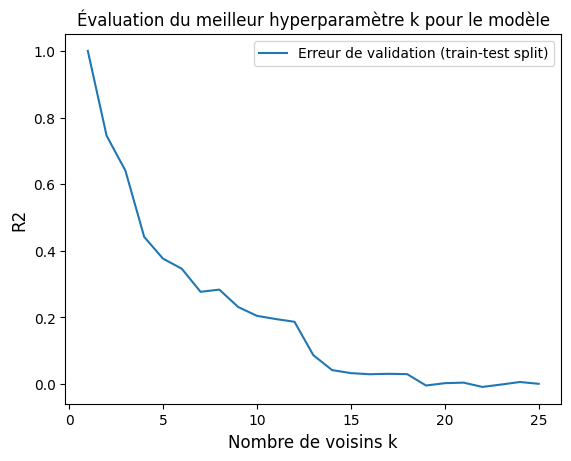

In [163]:
from sklearn.neighbors import KNeighborsRegressor
# On cherche à trouver le meilleur paramètre k pour la méthode KNN
nb_training = X_train.shape[0]
scores = []

for k in range(1, nb_training):
  neigh = KNeighborsRegressor(n_neighbors=k)
  neigh.fit(X_train, y_train)
  scores.append(neigh.score(X_train, y_train))

k_opt_val = np.argmax(scores) + 1  # C'est le k optimal (max)

print(f"Meilleur k validation : {k_opt_val}")

plt.plot(range(1, nb_training), scores, label="Erreur de validation (train-test split)")
plt.xlabel("Nombre de voisins k", fontsize=12)
plt.ylabel("R2", fontsize=12)
plt.title("Évaluation du meilleur hyperparamètre k pour le modèle", fontsize=12)
plt.legend()
plt.show()

In [164]:
# Charger le dataframe AuteursNat.csv et Auteurs.csv
df = pd.read_csv("data/AuteursNat.csv")
auteurs = pd.read_csv("data/Auteurs.csv", sep=" ")




In [165]:
corr = auteurs_adj.drop(columns=["voc"]).corrwith(df["Naissance"])
print(corr)

/Users/leajoseph/M1/S2/MLR/APST/APST-1/myenv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/leajoseph/M1/S2/MLR/APST/APST-1/myenv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


homme        0.074876
jour         0.183970
point       -0.245230
femme        0.146144
peu          0.156905
               ...   
labre        0.101213
pécore       0.101213
pourchas     0.101213
renoncule    0.101213
trouvère     0.101213
Length: 9604, dtype: float64


In [166]:
# Vérification après normalisation
print(f"Moyenne de X_train_scaled : {np.mean(X_train_scaled, axis=0)}")
print(f"Écart-type de X_train_scaled : {np.std(X_train_scaled, axis=0)}")


Moyenne de X_train_scaled : [-6.83214169e-17  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
Écart-type de X_train_scaled : [1. 1. 1. ... 0. 0. 0.]


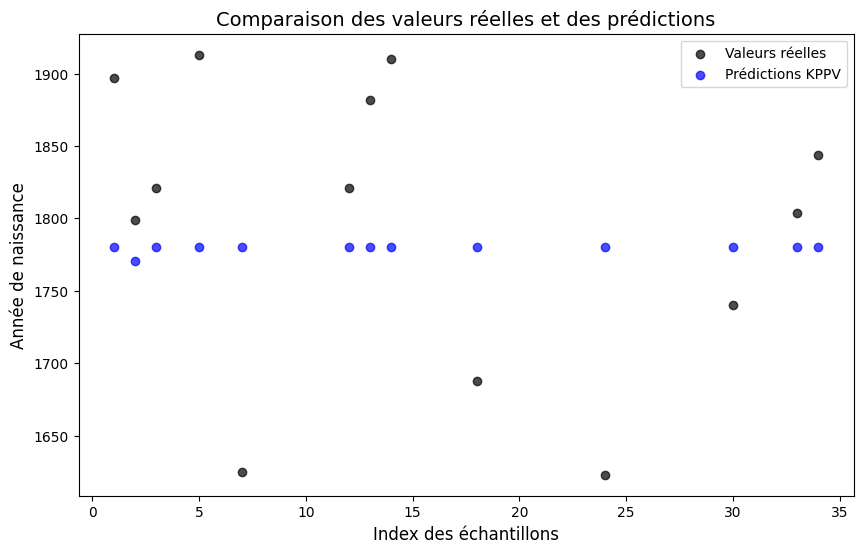

In [167]:
# Créer un DataFrame pour mieux gérer les données
results = pd.DataFrame({
    'Réel': y_test,
    'Prédiction KPPV': y_pred_kppv,
})

# Créer un graphique de comparaison
plt.figure(figsize=(10, 6))

# Tracer les valeurs réelles
plt.scatter(results.index, results['Réel'], color='black', label='Valeurs réelles', alpha=0.7)

# Tracer les prédictions de KPPV
plt.scatter(results.index, results['Prédiction KPPV'], color='blue', label='Prédictions KPPV', alpha=0.7)


# Ajouter des titres et labels
plt.title('Comparaison des valeurs réelles et des prédictions', fontsize=14)
plt.xlabel('Index des échantillons', fontsize=12)
plt.ylabel('Année de naissance', fontsize=12)
plt.legend()

# Afficher le graphique
plt.show()

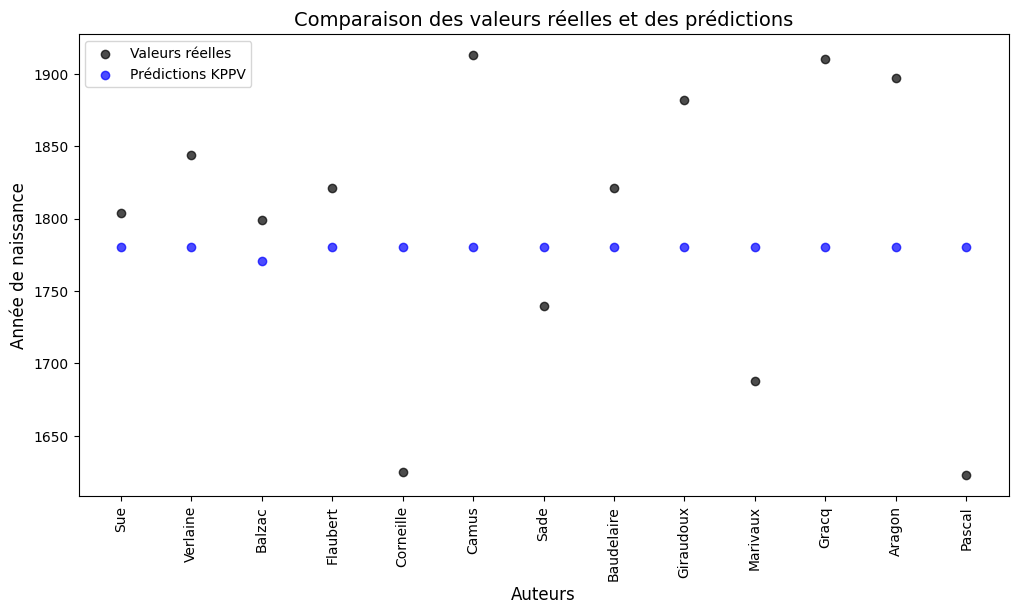

In [169]:
# Ajouter les noms des auteurs dans le DataFrame des résultats
results['Auteur'] = auteurs_adj["voc"].iloc[y_test.index].values  # Récupère les auteurs correspondant à y_test

# Créer un graphique de comparaison
plt.figure(figsize=(12, 6))

# Tracer les valeurs réelles
plt.scatter(results['Auteur'], results['Réel'], color='black', label='Valeurs réelles', alpha=0.7)

# Tracer les prédictions de KPPV
plt.scatter(results['Auteur'], results['Prédiction KPPV'], color='blue', label='Prédictions KPPV', alpha=0.7)


# Ajouter des titres et labels
plt.xticks(rotation=90)  # Faire pivoter les labels pour une meilleure lisibilité
plt.title('Comparaison des valeurs réelles et des prédictions', fontsize=14)
plt.xlabel('Auteurs', fontsize=12)
plt.ylabel('Année de naissance', fontsize=12)
plt.legend()

# Afficher le graphique
plt.show()


Meilleurs paramètres KPPV : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Meilleurs paramètres SVM : {'C': 10, 'gamma': 10, 'kernel': 'sigmoid'}
RMSE KPPV : 78.35411517144907
RMSE SVM : 98.45337313621398


/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_82195/1952209892.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['KPPV', 'SVM'], y=[rmse_kppv, rmse_svm], palette="viridis")


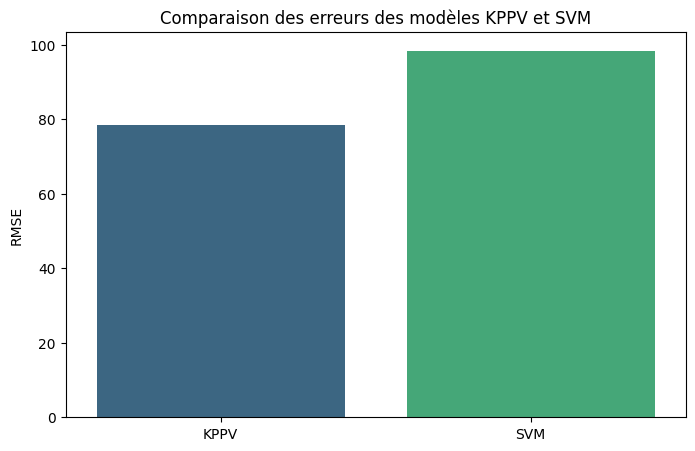

RMSE KPPV (CV) : 94.57183730605543
RMSE SVM (CV) : 74.73084019019433


In [171]:
# Charger les datasets
df = pd.read_csv("data/AuteursNat.csv")
auteurs = pd.read_csv("data/Auteurs.csv", sep=" ")

# Supprimer uniquement les colonnes où la première ligne (index 0) est "NOM"
auteurs_adj = auteurs.loc[:, auteurs.iloc[0] != "NOM"].copy()

# Ajouter la colonne 'voc' si elle n'existe pas déjà
if "voc" not in auteurs_adj.columns:
    auteurs_adj.insert(0, "voc", auteurs["voc"])

# Supprimer la ligne d'étiquettes grammaticales
auteurs_adj = auteurs_adj.drop(index=0).reset_index(drop=True)

# Définition des variables X (features) et y (target)
X = auteurs_adj.drop(columns=["voc"]).astype(float)
y = df["Naissance"]  # Variable cible (année de naissance)

# Séparation des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----- Modèle KPPV -----
kppv = KNeighborsRegressor()

# Optimisation des hyperparamètres de KPPV
param_grid_kppv = {
    "n_neighbors": [ 4, 5, 6, 7, 10, 15],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "weights": ["uniform", "distance"]
}

grid_search_kppv = GridSearchCV(kppv, param_grid_kppv, cv=5, n_jobs=-1)
grid_search_kppv.fit(X_train_scaled, y_train)

# Meilleurs paramètres et prédictions du modèle KPPV
kppv_best = grid_search_kppv.best_estimator_
y_pred_kppv = kppv_best.predict(X_test_scaled)

# ----- Modèle SVM -----
svm = SVR()

# Optimisation des hyperparamètres de SVM
param_grid_svm = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 3, 5, 8, 10, 100],
    "gamma": ["scale", "auto", 0.1, 1, 10]
}

grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, n_jobs=-1)
grid_search_svm.fit(X_train_scaled, y_train)

# Meilleurs paramètres et prédictions du modèle SVM
svm_best = grid_search_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

# ----- Évaluation des modèles -----
rmse_kppv = np.sqrt(mean_squared_error(y_test, y_pred_kppv))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

print(f"Meilleurs paramètres KPPV : {grid_search_kppv.best_params_}")
print(f"Meilleurs paramètres SVM : {grid_search_svm.best_params_}")
print(f"RMSE KPPV : {rmse_kppv}")
print(f"RMSE SVM : {rmse_svm}")

# Comparaison des erreurs avec un graphique
plt.figure(figsize=(8, 5))
sns.barplot(x=['KPPV', 'SVM'], y=[rmse_kppv, rmse_svm], palette="viridis")
plt.ylabel('RMSE')
plt.title('Comparaison des erreurs des modèles KPPV et SVM')
plt.show()

# Validation croisée pour une meilleure évaluation
rmse_kppv_cv = np.sqrt(-cross_val_score(kppv_best, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean())
rmse_svm_cv = np.sqrt(-cross_val_score(svm_best, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean())

print(f"RMSE KPPV (CV) : {rmse_kppv_cv}")
print(f"RMSE SVM (CV) : {rmse_svm_cv}")

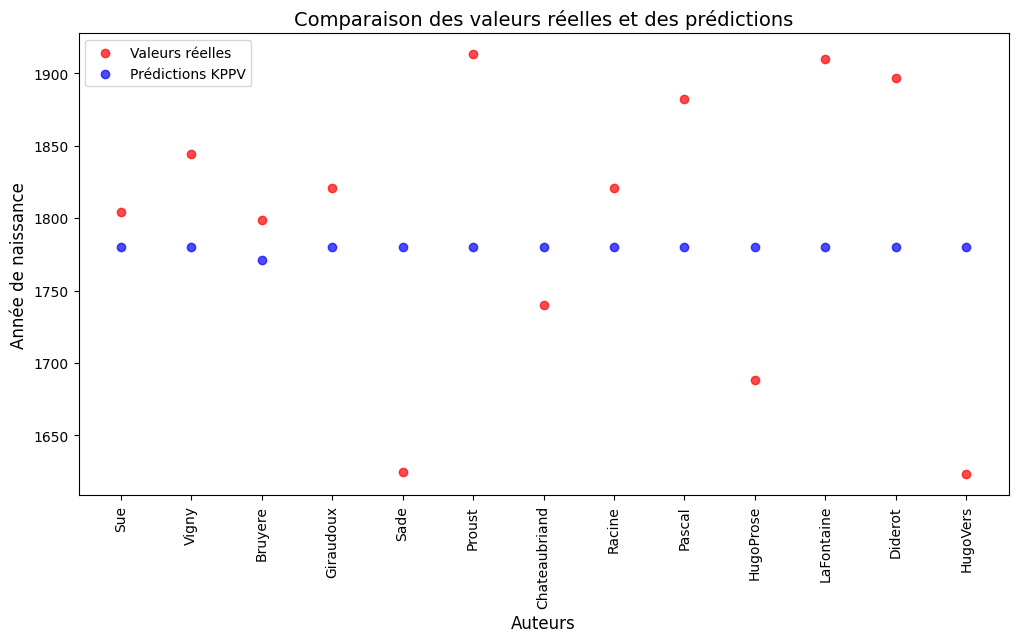

In [172]:
# Ajouter les noms des auteurs dans le DataFrame des résultats
results['Auteur'] = auteurs_adj["voc"].iloc[y_test.index].values  # Récupère les auteurs correspondant à y_test

# Créer un graphique de comparaison
plt.figure(figsize=(12, 6))

# Tracer les valeurs réelles
plt.scatter(results['Auteur'], results['Réel'], color='red', label='Valeurs réelles', alpha=0.7)

# Tracer les prédictions de KPPV
plt.scatter(results['Auteur'], results['Prédiction KPPV'], color='blue', label='Prédictions KPPV', alpha=0.7)


# Ajouter des titres et labels
plt.xticks(rotation=90)  # Faire pivoter les labels pour une meilleure lisibilité
plt.title('Comparaison des valeurs réelles et des prédictions', fontsize=14)
plt.xlabel('Auteurs', fontsize=12)
plt.ylabel('Année de naissance', fontsize=12)
plt.legend()

# Afficher le graphique
plt.show()


# Avec toutes les données

test régression ridge